In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter
from matplotlib.colors import ListedColormap
from pathlib import Path
import sys
import scanpy as sc
from scipy import stats
from statsmodels.stats.multitest import multipletests

In [2]:
# change here if you changed your directory
def here():
    try:
        return Path(__file__).resolve().parent   # script file’s folder
    except NameError:
        return Path.cwd().resolve()              # notebook/REPL

processed_data = (here().parents[1] / "2024_Nov" / "Processed_data").resolve()

In [3]:
# correlation_directory = "../2024_Nov/HiExpr_correlation_info_matrix/"

In [4]:
# csv_paths_list = []
# # Loop through the inner directories and files
# for root, dirs, files in os.walk(correlation_directory):
#     # Skip the root directory itself
#     if root == correlation_directory:
#         continue
    
#     # Loop through the files in the current inner directory
#     for file in files:
#         if file.endswith('.csv'):
#             # Get the full path and store it
#             full_path = os.path.join(root, file)
#             csv_paths_list.append(full_path)

# csv_paths_list = sorted(csv_paths_list)

In [5]:
pred_cor_df = pd.DataFrame([])

In [6]:
def generate_corr (adata, organ_celltype):
    corr_vals = []
    p_vals = []
    genes_kept = []
    norm_counts = pd.DataFrame(
        data = adata.X.toarray(),
        index = adata.obs_names,
        columns = adata.var_names
    ).T
    ages = [int(x.strip("m")) for x in adata.obs["pred_age"]]
#     display(norm_counts)
    for gene in list(norm_counts.index):
        expr = norm_counts.loc[gene].values
        if expr.sum() != 0 and np.std(expr) > 0:
            r, p = stats.pearsonr(expr, ages)
            genes_kept.append(gene)
            corr_vals.append(r)
            p_vals.append(p)
    df = pd.DataFrame({
        "Pearson Correlation": corr_vals,
        "P-values": p_vals,
        "Category": [organ_celltype] * len(corr_vals)
    }, index=genes_kept)
    return df

In [7]:
for filename in os.listdir(processed_data):
    if filename.endswith(".h5ad"):
        file_path = os.path.join(processed_data, filename)
        anndata = sc.read_h5ad(file_path)
        organ = filename.split("_")[0]
        print(f"Processing {organ} =======================================================")
        celltypes = np.unique(anndata.obs["cell_ontology_class"])
        for celltype in celltypes:
            sub_adata = anndata[anndata.obs["cell_ontology_class"] == celltype]
            result = generate_corr(sub_adata, f"{organ}_{celltype}")
            pred_cor_df = pd.concat([pred_cor_df, result])

Processing Limb-Muscle =======================================================
Processing Brain =======================================================
Processing Heart =======================================================
Processing Lung =======================================================
Processing Bladder =======================================================
Processing Liver =======================================================
Processing Kidney =======================================================
Processing Bone-Marrow =======================================================


In [8]:
pred_cor_df

,Pearson Correlation,P-values,Category
Sox17,-0.024136,0.506450,Limb-Muscle_B cell
Mrpl15,0.036063,0.320777,Limb-Muscle_B cell
Lypla1,0.000188,0.995866,Limb-Muscle_B cell
Tcea1,0.031834,0.380828,Limb-Muscle_B cell
Atp6v1h,0.017989,0.620491,Limb-Muscle_B cell
...,...,...,...
Kdm5d,-0.020912,0.346811,Bone-Marrow_promonocyte
Eif2s3y,-0.027111,0.222556,Bone-Marrow_promonocyte
Uty,-0.045443,0.040831,Bone-Marrow_promonocyte
Ddx3y,-0.060229,0.006693,Bone-Marrow_promonocyte


In [9]:
# from statsmodels.stats.multitest import multipletests

# categories = []
# # counts = []
# concatenated = pd.DataFrame()

# for file_path in csv_paths_list:
#     all_dataframes = {}
#     organ_name = file_path.split("/")[3].split("_")[2]
#     if (file_path.endswith('.csv')):
#         name = file_path.split("/")[-1].split("_")[2]
#         df = pd.read_csv(file_path, index_col=0)
#         df = df.dropna()
#         df['Category'] = "_".join([organ_name, name])
#         concatenated = pd.concat([concatenated, df])

In [10]:
# concatenated

In [11]:
pred_cor_df["Category"].unique()

array(['Limb-Muscle_B cell', 'Limb-Muscle_T cell',
       'Limb-Muscle_endothelial cell', 'Limb-Muscle_macrophage',
       'Limb-Muscle_mesenchymal stem cell',
       'Limb-Muscle_skeletal muscle satellite cell',
       'Limb-Muscle_smooth muscle cell', 'Brain_endothelial cell',
       'Brain_microglial cell', 'Brain_oligodendrocyte',
       'Heart_endothelial cell of coronary artery',
       'Heart_fibroblast of cardiac tissue', 'Heart_leukocyte',
       'Lung_endothelial cell', 'Lung_lymphocyte', 'Lung_macrophage',
       'Lung_monocyte', 'Lung_stromal cell', 'Bladder_bladder cell',
       'Bladder_bladder urothelial cell', 'Liver_Kupffer cell',
       'Liver_hepatocyte', 'Kidney_epithelial cell of proximal tubule',
       'Kidney_fenestrated cell',
       'Kidney_kidney loop of Henle thick ascending limb epithelial cell',
       'Kidney_kidney proximal convoluted tubule epithelial cell',
       'Kidney_macrophage', 'Bone-Marrow_erythroblast',
       'Bone-Marrow_granulocyte', 'Bone-

## Using False Discovery Rate (FDR) correction to correct p values and generate more trustworthy results

In [12]:
adj_pvalues = multipletests(np.array(pred_cor_df["P-values"]), method = "fdr_bh")[1]
pred_cor_df["adjP-values"] = adj_pvalues
pred_cor_df

,Pearson Correlation,P-values,Category,adjP-values
Sox17,-0.024136,0.506450,Limb-Muscle_B cell,0.681501
Mrpl15,0.036063,0.320777,Limb-Muscle_B cell,0.515901
Lypla1,0.000188,0.995866,Limb-Muscle_B cell,0.997701
Tcea1,0.031834,0.380828,Limb-Muscle_B cell,0.574391
Atp6v1h,0.017989,0.620491,Limb-Muscle_B cell,0.769233
...,...,...,...,...
Kdm5d,-0.020912,0.346811,Bone-Marrow_promonocyte,0.540204
Eif2s3y,-0.027111,0.222556,Bone-Marrow_promonocyte,0.407329
Uty,-0.045443,0.040831,Bone-Marrow_promonocyte,0.116923
Ddx3y,-0.060229,0.006693,Bone-Marrow_promonocyte,0.026434


In [13]:
# Cap the values to 1e-10, anything that is more than 1e-10 will be 1e-10
pred_cor_df["adjP-values"] = np.where(
    pred_cor_df["adjP-values"] < 1e-10, 
    1e-10, 
    pred_cor_df["adjP-values"]
)

### do the logp-value here

In [14]:
pred_cor_df["log-adjP-values"] = np.log10(pred_cor_df["adjP-values"])
pred_cor_df

,Pearson Correlation,P-values,Category,adjP-values,log-adjP-values
Sox17,-0.024136,0.506450,Limb-Muscle_B cell,0.681501,-0.166533
Mrpl15,0.036063,0.320777,Limb-Muscle_B cell,0.515901,-0.287434
Lypla1,0.000188,0.995866,Limb-Muscle_B cell,0.997701,-0.001000
Tcea1,0.031834,0.380828,Limb-Muscle_B cell,0.574391,-0.240792
Atp6v1h,0.017989,0.620491,Limb-Muscle_B cell,0.769233,-0.113942
...,...,...,...,...,...
Kdm5d,-0.020912,0.346811,Bone-Marrow_promonocyte,0.540204,-0.267442
Eif2s3y,-0.027111,0.222556,Bone-Marrow_promonocyte,0.407329,-0.390055
Uty,-0.045443,0.040831,Bone-Marrow_promonocyte,0.116923,-0.932100
Ddx3y,-0.060229,0.006693,Bone-Marrow_promonocyte,0.026434,-1.577835


In [15]:
sig_counts = pred_cor_df[(pred_cor_df['adjP-values'] < 0.05)]
value_matrix = sig_counts.set_index(['Category', sig_counts.index])['Pearson Correlation'].unstack()
value_matrix = value_matrix.fillna(0)

In [16]:
value_matrix = value_matrix.rename(
    index={"Kidney_kidney loop of Henle thick ascending limb epithelial cell": "Kidney TAL epith cell",
          "Bone-Marrow_megakaryocyte-erythroid progenitor cell": "Bone-Marrow MEP cell",
          "Kidney_kidney proximal convoluted tubule epithelial cell": "Kidney_PCT_epith cell"}
)

In [17]:
value_matrix.shape

(36, 17090)

/Users/chanyue/anaconda3/envs/scanpy/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


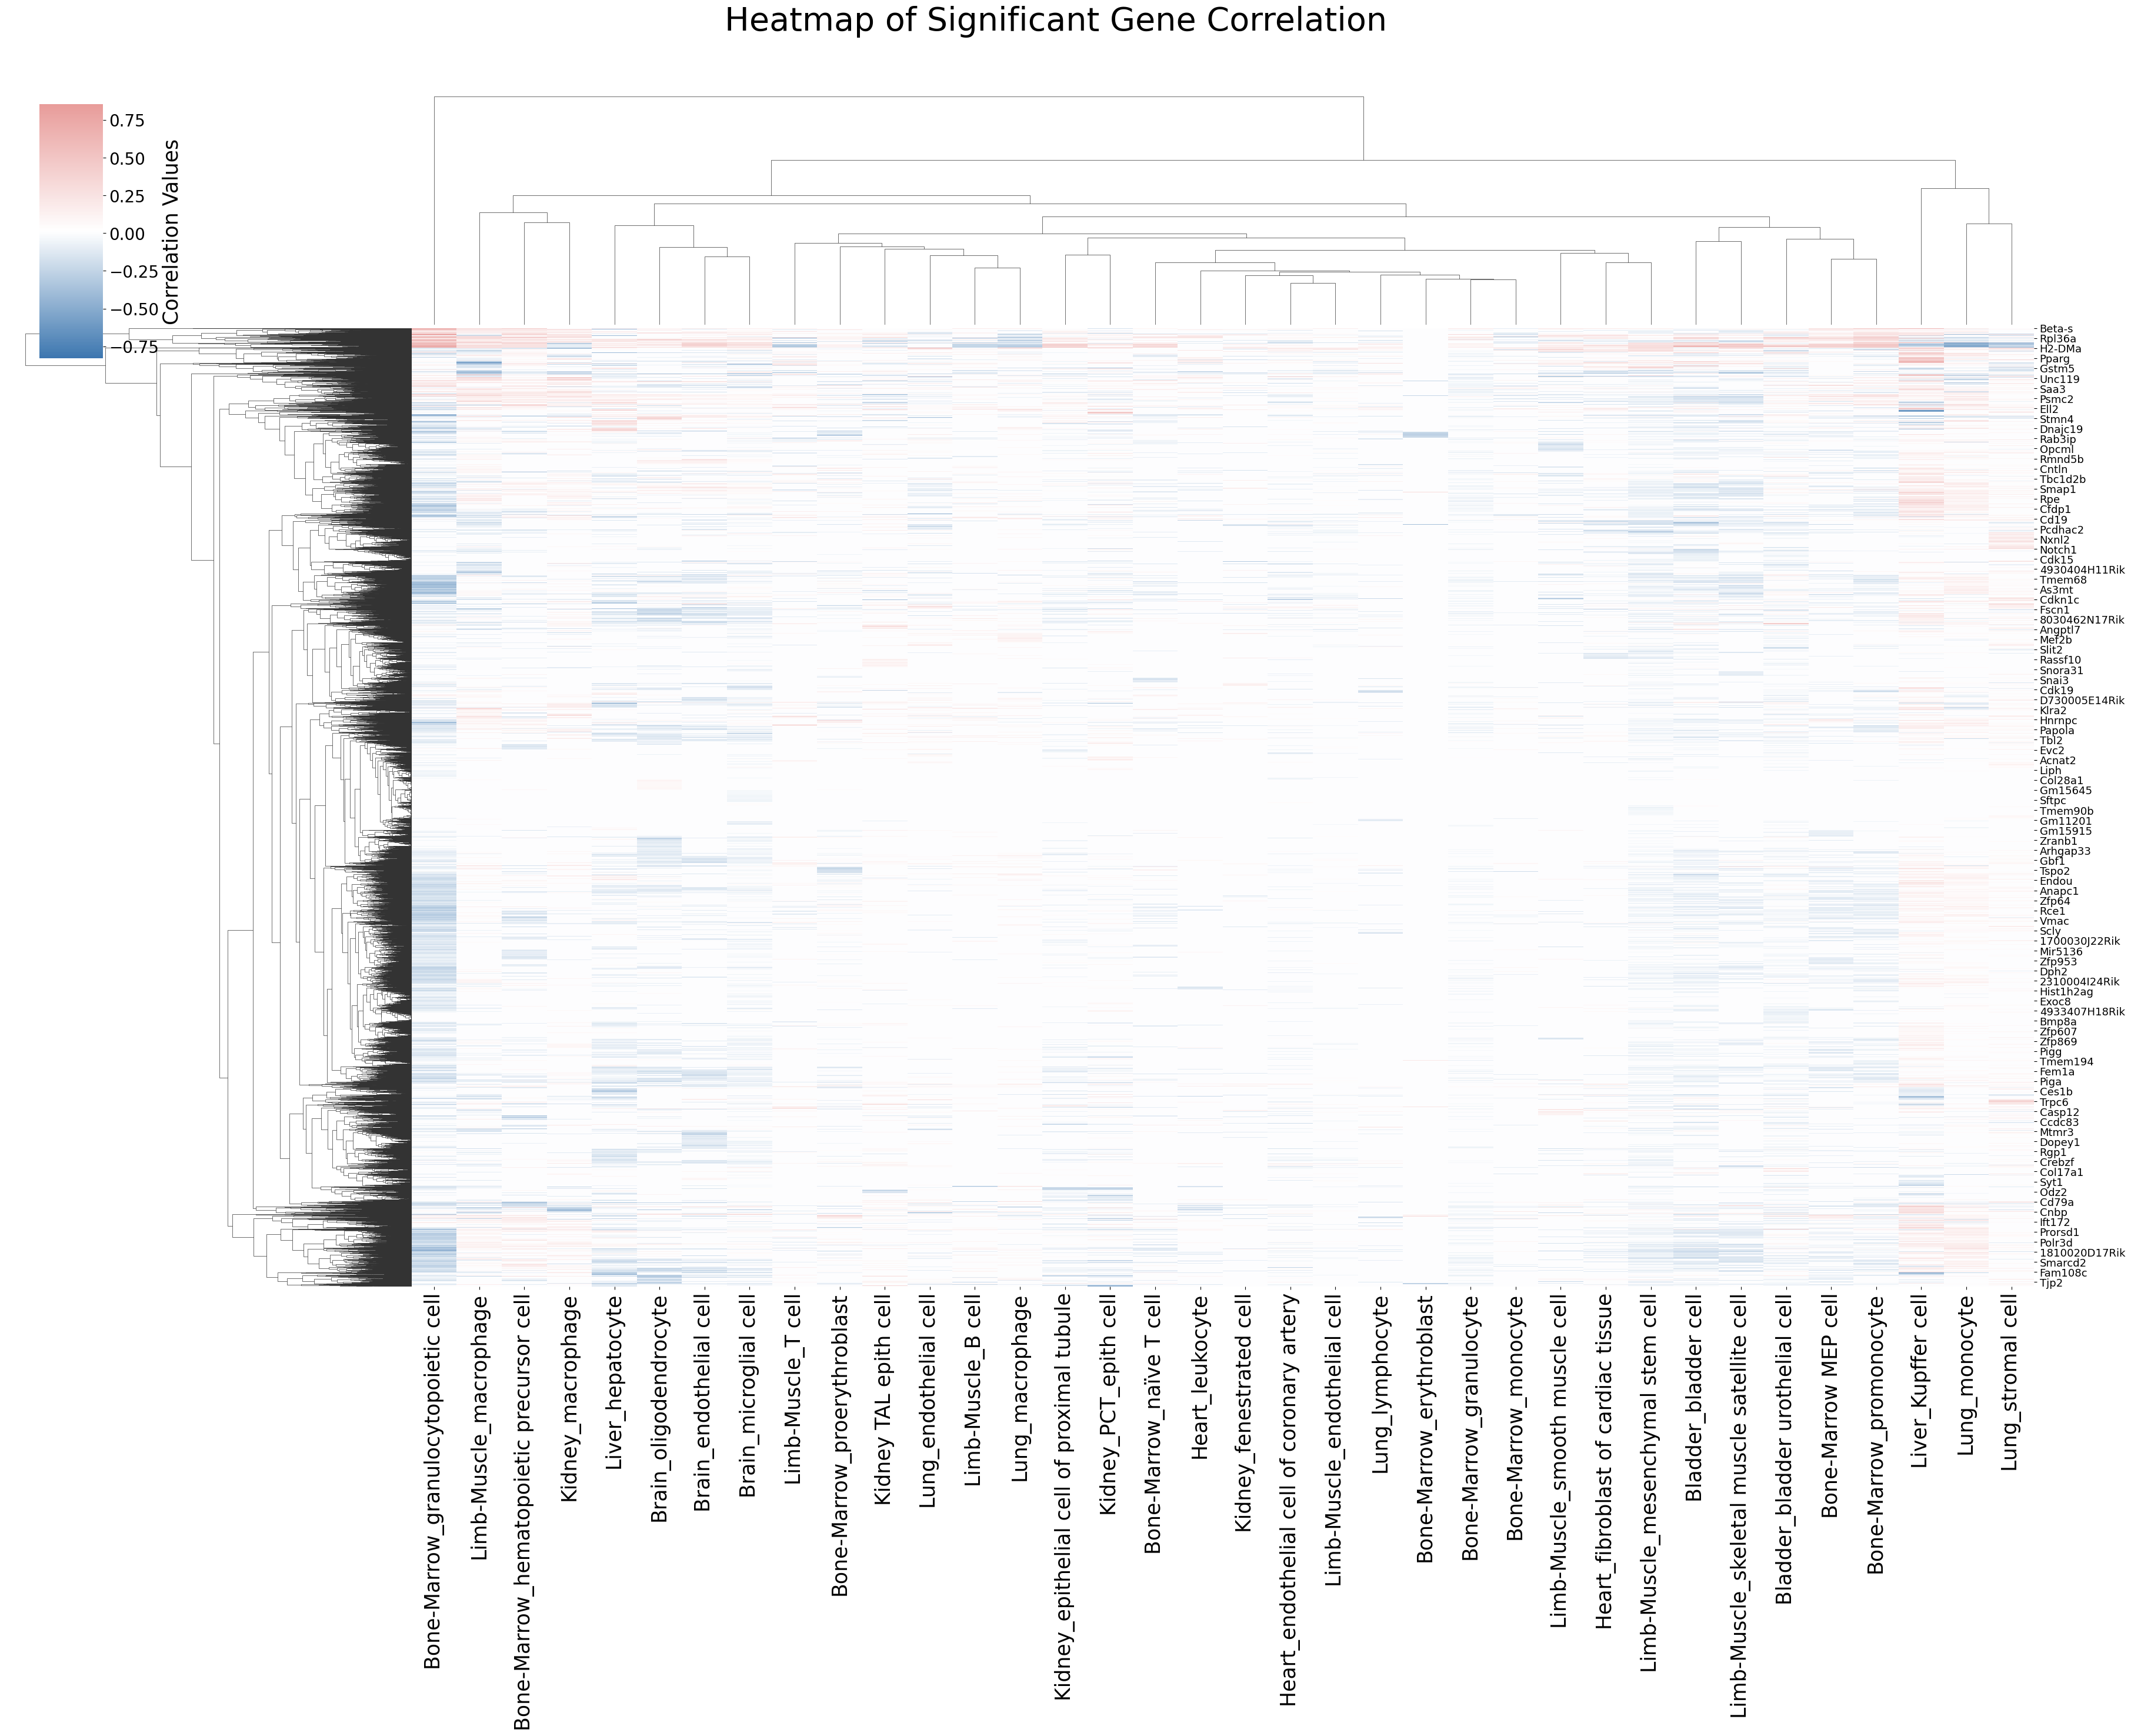

In [18]:
# Plot the heatmap
from matplotlib.colors import LinearSegmentedColormap

cmap = LinearSegmentedColormap.from_list("custom_diverging", ["#3C76AF", "white", "#E89C9A"])
clustermap_dist = sns.clustermap(value_matrix.T, cmap=cmap, 
                                 method='complete', metric='euclidean', figsize=(36, 24))

clustermap_dist.cax.set_position([
    0.02,                         # x-position (further right = less wide)
    clustermap_dist.cax.get_position().y0,
    0.03,                         # width (make this smaller)
    clustermap_dist.cax.get_position().height
])
clustermap_dist.fig.suptitle('Heatmap of Significant Gene Correlation', 
                             fontsize=40, y=1.05)
clustermap_dist.ax_heatmap.set_xlabel("")

clustermap_dist.cax.tick_params(labelsize=20)
plt.ylabel('Correlation Values', fontsize=25)
plt.setp(clustermap_dist.ax_heatmap.get_xticklabels(), fontsize=25)
plt.setp(clustermap_dist.ax_heatmap.get_yticklabels(), fontsize=13)

plt.savefig(f"./Clustermap_of_Gene_Correlation_Filtered_by_adjusted_p_values_across_Celltypes.png", 
            bbox_inches='tight', dpi=300)

plt.show()
plt.close()

## Compute the ranking of the genes by sum log-adjusted-pvalues

In [19]:
result = pred_cor_df.groupby(pred_cor_df.index).agg({
    'log-adjP-values': 'sum',
    'adjP-values': lambda x: list(x),  # Keep the original P-values as lists
    'Category': lambda x: list(x.unique())  # Keep unique categories
})
result = result.rename(columns={"log-adjP-values": "Sum log-adjP-values"})
result['Sum log-adjP-values'].replace(-np.inf, np.nan, inplace=True)
result['Sum log-adjP-values'].fillna(-1e99, inplace=True)
result = result.sort_values(by='Sum log-adjP-values', ascending=True)

In [20]:
result

,Sum log-adjP-values,adjP-values,Category
S100a6,-277.219169,"[2.6556507180399598e-05, 1e-10, 1e-10, 1e-10, ...","[Limb-Muscle_B cell, Limb-Muscle_T cell, Limb-..."
Rps28,-261.167121,"[6.932116425352863e-07, 1e-10, 1.0608914766104...","[Limb-Muscle_B cell, Limb-Muscle_T cell, Limb-..."
Fau,-260.873205,"[1.7195769389615284e-10, 0.0002273632403166938...","[Limb-Muscle_B cell, Limb-Muscle_T cell, Limb-..."
Rps6,-259.136536,"[6.03319235146664e-08, 1e-10, 0.87987824172074...","[Limb-Muscle_B cell, Limb-Muscle_T cell, Limb-..."
Rps5,-258.953780,"[5.415924819930172e-10, 1e-10, 0.7777622921161...","[Limb-Muscle_B cell, Limb-Muscle_T cell, Limb-..."
...,...,...,...
Synb,-0.015707,[0.9644783926963808],[Bone-Marrow_proerythroblast]
Avpr1b,-0.013731,[0.9688779147953872],[Brain_microglial cell]
4932414J04Rik,-0.005442,[0.9875466703429312],[Brain_microglial cell]
Olfr555,-0.001000,[0.9977009147634446],[Brain_microglial cell]


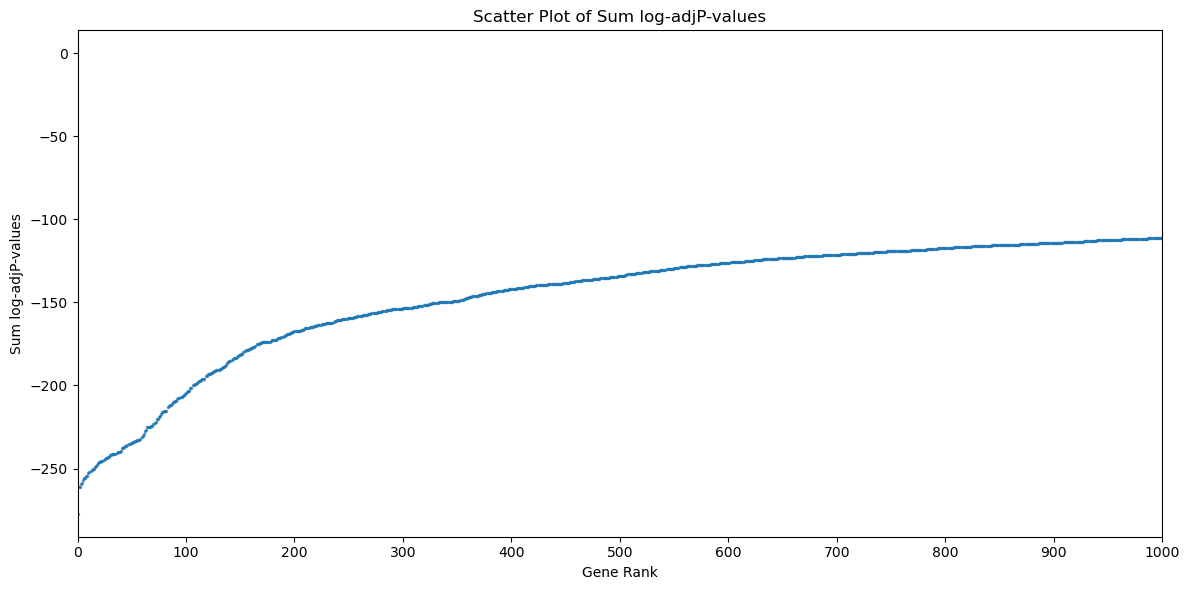

In [21]:
plt.figure(figsize=(12, 6))
plt.scatter(range(len(result)), result["Sum log-adjP-values"], s=2, alpha=0.7)
plt.xlabel("Gene Rank")
plt.ylabel("Sum log-adjP-values")
plt.title("Scatter Plot of Sum log-adjP-values")
plt.xlim(0, 1000)
plt.xticks(range(0, 1001, 100))
plt.tight_layout()
plt.show()

In [22]:
result.to_csv("./all_significant_markers.csv")

In [23]:
top100 = result.head(100)
top100

,Sum log-adjP-values,adjP-values,Category
S100a6,-277.219169,"[2.6556507180399598e-05, 1e-10, 1e-10, 1e-10, ...","[Limb-Muscle_B cell, Limb-Muscle_T cell, Limb-..."
Rps28,-261.167121,"[6.932116425352863e-07, 1e-10, 1.0608914766104...","[Limb-Muscle_B cell, Limb-Muscle_T cell, Limb-..."
Fau,-260.873205,"[1.7195769389615284e-10, 0.0002273632403166938...","[Limb-Muscle_B cell, Limb-Muscle_T cell, Limb-..."
Rps6,-259.136536,"[6.03319235146664e-08, 1e-10, 0.87987824172074...","[Limb-Muscle_B cell, Limb-Muscle_T cell, Limb-..."
Rps5,-258.953780,"[5.415924819930172e-10, 1e-10, 0.7777622921161...","[Limb-Muscle_B cell, Limb-Muscle_T cell, Limb-..."
...,...,...,...
Eef2,-207.127148,"[1.3409264685876557e-07, 1e-10, 0.000305949411...","[Limb-Muscle_B cell, Limb-Muscle_T cell, Limb-..."
Rpl36a,-206.709715,"[2.9898159269033417e-06, 1e-10, 0.070587283881...","[Limb-Muscle_B cell, Limb-Muscle_T cell, Limb-..."
S100a11,-206.355960,"[0.00024105838776604315, 1e-10, 0.956131336455...","[Limb-Muscle_B cell, Limb-Muscle_T cell, Limb-..."
Rpl5,-205.595092,"[1e-10, 1e-10, 0.6740478055142353, 1e-10, 1e-1...","[Limb-Muscle_B cell, Limb-Muscle_T cell, Limb-..."


In [24]:
top100.to_csv("./Top100_Sig_Genes_final.csv")

In [25]:
display(result.tail(100))  # Show the last 100 rows

,Sum log-adjP-values,adjP-values,Category
4732456N10Rik,-0.123968,[0.7516791343484045],[Brain_microglial cell]
Mir130a,-0.122344,"[0.8139306446679861, 0.9269760520088478]","[Brain_microglial cell, Brain_oligodendrocyte]"
Pcdha4,-0.119331,"[0.9879672664576451, 0.7690001523359347]","[Brain_endothelial cell, Brain_oligodendrocyte]"
Mbd3l2,-0.118660,[0.7609215299104642],[Brain_microglial cell]
Cngb3,-0.118660,[0.7609215299104642],[Brain_microglial cell]
...,...,...,...
Synb,-0.015707,[0.9644783926963808],[Bone-Marrow_proerythroblast]
Avpr1b,-0.013731,[0.9688779147953872],[Brain_microglial cell]
4932414J04Rik,-0.005442,[0.9875466703429312],[Brain_microglial cell]
Olfr555,-0.001000,[0.9977009147634446],[Brain_microglial cell]


In [26]:
result.tail(100).to_csv("./Bottom100_Sig_Genes_final.csv")

In [27]:
top100_genes_df = top100.explode(['adjP-values', 'Category'])

In [28]:
top100_genes_df['adjP-values'] = top100_genes_df['adjP-values'].fillna(0)

In [29]:
## handle the values that are 0 cause it might result -inf and not showing up in the figure later
top100_genes_df['adjP-values'] = top100_genes_df['adjP-values'].replace(0, 1e-99).astype(float)

top100_genes_df['adjP-values'] = top100_genes_df['adjP-values'].astype(float)

top100_genes_df

,Sum log-adjP-values,adjP-values,Category
S100a6,-277.219169,2.655651e-05,Limb-Muscle_B cell
S100a6,-277.219169,1.000000e-10,Limb-Muscle_T cell
S100a6,-277.219169,1.000000e-10,Limb-Muscle_endothelial cell
S100a6,-277.219169,1.000000e-10,Limb-Muscle_macrophage
S100a6,-277.219169,1.000000e-10,Limb-Muscle_mesenchymal stem cell
...,...,...,...
Cfl1,-205.193120,1.000000e-10,Bone-Marrow_megakaryocyte-erythroid progenitor...
Cfl1,-205.193120,2.647255e-06,Bone-Marrow_monocyte
Cfl1,-205.193120,7.946705e-02,Bone-Marrow_naïve T cell
Cfl1,-205.193120,2.357945e-08,Bone-Marrow_proerythroblast


In [30]:
## reset the index to obtain the gene names
top100_genes_df = top100_genes_df.reset_index()
top100_genes_df

,index,Sum log-adjP-values,adjP-values,Category
0,S100a6,-277.219169,2.655651e-05,Limb-Muscle_B cell
1,S100a6,-277.219169,1.000000e-10,Limb-Muscle_T cell
2,S100a6,-277.219169,1.000000e-10,Limb-Muscle_endothelial cell
3,S100a6,-277.219169,1.000000e-10,Limb-Muscle_macrophage
4,S100a6,-277.219169,1.000000e-10,Limb-Muscle_mesenchymal stem cell
...,...,...,...,...
3591,Cfl1,-205.193120,1.000000e-10,Bone-Marrow_megakaryocyte-erythroid progenitor...
3592,Cfl1,-205.193120,2.647255e-06,Bone-Marrow_monocyte
3593,Cfl1,-205.193120,7.946705e-02,Bone-Marrow_naïve T cell
3594,Cfl1,-205.193120,2.357945e-08,Bone-Marrow_proerythroblast


In [31]:
# Keep the ranking
ordered_genes = list(top100.index)
# Pivot the data to create a matrix with genes (index) as rows, categories as columns, and adjP-values as values
heatmap_data = top100_genes_df.pivot_table(index='index', columns='Category', values='adjP-values')
# Reorder the rows in the heatmap_data DataFrame according to the original order in ordered_genes
heatmap_data = heatmap_data.reindex(ordered_genes)
# Apply -log10 transformation to highlight significant p-values
log_p_values = -np.log10(heatmap_data)

In [32]:
log_p_values

Category,Bladder_bladder cell,Bladder_bladder urothelial cell,Bone-Marrow_erythroblast,Bone-Marrow_granulocyte,Bone-Marrow_granulocytopoietic cell,Bone-Marrow_hematopoietic precursor cell,Bone-Marrow_megakaryocyte-erythroid progenitor cell,Bone-Marrow_monocyte,Bone-Marrow_naïve T cell,Bone-Marrow_proerythroblast,...,Limb-Muscle_mesenchymal stem cell,Limb-Muscle_skeletal muscle satellite cell,Limb-Muscle_smooth muscle cell,Liver_Kupffer cell,Liver_hepatocyte,Lung_endothelial cell,Lung_lymphocyte,Lung_macrophage,Lung_monocyte,Lung_stromal cell
index,,,,,,,,,,,,,,,,,,,,,
S100a6,10.000000,10.0,4.470081,10.000000,10.000000,10.000000,10.0,5.045560,10.000000,10.000000,...,10.000000,3.277539,10.000000,7.675821,2.422816,0.009646,10.000000,0.017859,10.000000,10.000000
Rps28,10.000000,10.0,0.188064,1.188319,10.000000,7.998710,10.0,0.145480,10.000000,10.000000,...,10.000000,10.000000,2.072683,10.000000,2.544240,1.503760,1.331027,10.000000,10.000000,10.000000
Fau,10.000000,10.0,0.003627,10.000000,10.000000,10.000000,10.0,0.781190,10.000000,10.000000,...,10.000000,10.000000,1.835367,10.000000,10.000000,0.420704,2.204261,10.000000,10.000000,10.000000
Rps6,10.000000,10.0,0.119261,10.000000,10.000000,10.000000,10.0,0.274847,10.000000,7.483561,...,10.000000,10.000000,0.880996,10.000000,10.000000,0.745423,0.115591,10.000000,10.000000,10.000000
Rps5,10.000000,10.0,1.681339,8.115700,10.000000,10.000000,10.0,0.255470,10.000000,10.000000,...,10.000000,10.000000,2.566277,10.000000,3.686258,0.091108,0.028426,10.000000,10.000000,10.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Eef2,10.000000,10.0,1.242108,4.556400,0.687743,7.129370,10.0,0.632273,5.869365,0.345387,...,10.000000,10.000000,0.217570,10.000000,3.073761,1.866671,0.186495,6.284796,9.281709,0.162814
Rpl36a,10.000000,10.0,0.273798,1.029569,9.987818,9.755176,10.0,0.978119,10.000000,3.663564,...,10.000000,10.000000,0.909963,4.567251,1.298631,0.188468,0.292772,10.000000,10.000000,10.000000
S100a11,10.000000,10.0,0.544035,10.000000,10.000000,10.000000,10.0,6.027984,3.197642,10.000000,...,10.000000,2.541752,3.129719,2.591355,2.751370,0.335490,10.000000,0.376304,10.000000,10.000000


In [33]:
log_p_values_sorted = log_p_values.sort_index()
log_p_values_sorted

Category,Bladder_bladder cell,Bladder_bladder urothelial cell,Bone-Marrow_erythroblast,Bone-Marrow_granulocyte,Bone-Marrow_granulocytopoietic cell,Bone-Marrow_hematopoietic precursor cell,Bone-Marrow_megakaryocyte-erythroid progenitor cell,Bone-Marrow_monocyte,Bone-Marrow_naïve T cell,Bone-Marrow_proerythroblast,...,Limb-Muscle_mesenchymal stem cell,Limb-Muscle_skeletal muscle satellite cell,Limb-Muscle_smooth muscle cell,Liver_Kupffer cell,Liver_hepatocyte,Lung_endothelial cell,Lung_lymphocyte,Lung_macrophage,Lung_monocyte,Lung_stromal cell
index,,,,,,,,,,,,,,,,,,,,,
Actb,9.915695,10.000000,1.455776,10.000000,10.000000,10.000000,10.000000,3.984339,10.000000,1.769953,...,10.000000,10.000000,0.488686,10.000000,0.867496,6.120650,1.266656,7.993954,10.0,10.000000
Atp5l,10.000000,10.000000,0.021945,7.923029,10.000000,10.000000,10.000000,2.595293,1.730150,4.234377,...,1.582436,4.833116,3.929054,10.000000,10.000000,2.060980,0.586192,7.930599,10.0,2.134159
B2m,10.000000,9.838448,1.169849,10.000000,10.000000,5.996624,9.876855,3.129858,10.000000,5.659351,...,10.000000,10.000000,10.000000,2.068319,10.000000,2.115998,7.489597,0.502612,10.0,10.000000
Beta-s,0.725387,0.289164,0.175329,10.000000,10.000000,10.000000,10.000000,1.107613,10.000000,0.052797,...,10.000000,2.693265,0.993358,10.000000,8.406509,10.000000,10.000000,10.000000,10.0,10.000000
Cfl1,9.622562,10.000000,1.116195,10.000000,10.000000,10.000000,10.000000,5.577204,1.099813,7.627466,...,0.953235,0.455934,0.061138,10.000000,8.479547,3.750268,0.279587,10.000000,10.0,0.146775
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Sparc,10.000000,10.000000,0.975568,7.962821,4.760335,2.895929,0.658004,0.077867,0.430589,1.053586,...,10.000000,10.000000,0.371330,10.000000,2.566783,1.812328,3.369891,10.000000,10.0,10.000000
Tmsb10,10.000000,0.457555,0.386781,0.952045,10.000000,10.000000,3.618934,6.029904,6.299046,0.209373,...,10.000000,0.452156,10.000000,10.000000,0.299124,3.419235,1.818059,10.000000,10.0,10.000000
Tmsb4x,10.000000,10.000000,0.758361,10.000000,10.000000,10.000000,10.000000,1.726163,10.000000,7.332924,...,10.000000,5.059749,10.000000,10.000000,0.085169,1.006047,5.816582,10.000000,10.0,10.000000


In [34]:
log_p_values_sorted = log_p_values_sorted.rename(
    columns={"Kidney_kidney loop of Henle thick ascending limb epithelial cell": "Kidney_TAL epith cell",
          "Bone-Marrow_megakaryocyte-erythroid progenitor cell": "Bone-Marrow_MEP cell",
          "Kidney_kidney proximal convoluted tubule epithelial cell": "Kidney_PCT-epith cell"}
)

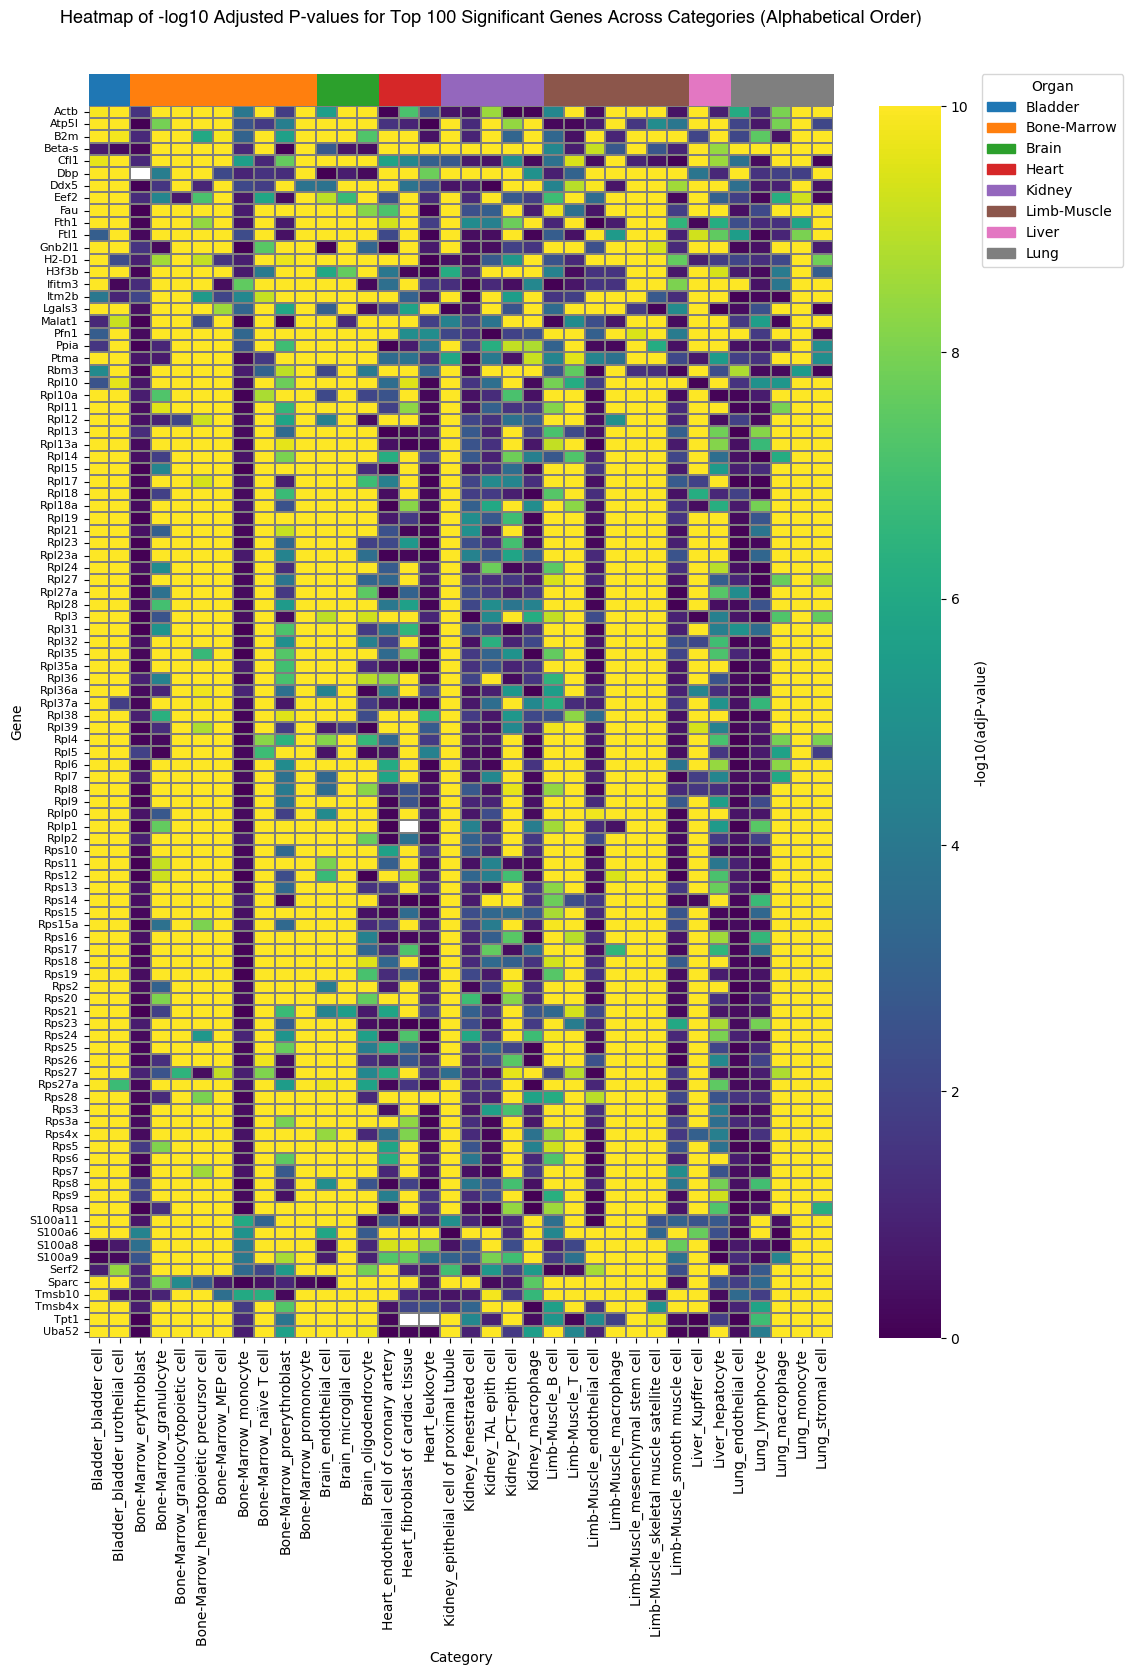

In [35]:
base_cmap = sns.color_palette("viridis", as_cmap=True)
colors = base_cmap(np.linspace(0, 1, 256))
custom_cmap = ListedColormap(colors)

fig, ax = plt.subplots(figsize=(12, 16))
ax.tick_params(axis='y', labelsize=8)
sns.heatmap(
    log_p_values_sorted, cmap=custom_cmap, cbar_kws={'label': '-log10(adjP-value)'},
    linewidths=0.1, linecolor='grey', xticklabels=True, yticklabels=True,
    mask=log_p_values_sorted.isna(), ax=ax, vmin=0
)

heatmap_pos = ax.get_position()
bar_height = 0.02  # Height of the annotation bar
top_ax = fig.add_axes([heatmap_pos.x0, heatmap_pos.y1, heatmap_pos.width, bar_height])

organ_names = log_p_values_sorted.columns.str.split('_').str[0]
unique_organs = organ_names.unique()
palette = sns.color_palette("tab10", len(unique_organs))
organ_color_map = dict(zip(unique_organs, palette))
organ_colors_rgb = np.array([organ_color_map[organ] for organ in organ_names], dtype=float)

top_ax.imshow([organ_colors_rgb], aspect="auto", interpolation="nearest")
top_ax.set_xticks(np.arange(len(organ_colors_rgb)) + 0.5, minor=True)
top_ax.grid(which="minor", color="grey", linestyle="-", linewidth=0.5)
top_ax.tick_params(which="minor", size=0)
top_ax.axis("off")

legend_patches = [mpatches.Patch(color=color, label=organ) for organ, color in organ_color_map.items()]
plt.legend(handles=legend_patches, title="Organ", bbox_to_anchor=(1.2, 1), loc='upper left', borderaxespad=0.)

plt.suptitle('Heatmap of -log10 Adjusted P-values for Top 100 Significant Genes Across Categories (Alphabetical Order)', x=0.46, y=0.94, fontname="helvetica", fontsize=13)
ax.set_xlabel('Category')
ax.set_ylabel('Gene')
plt.setp(ax.get_xticklabels(), rotation=90)

fig.savefig("Top100_Sig_Genes_-log10_values_ranked_by_sum.png", bbox_inches='tight', dpi = 600)
plt.show()

## Plotting the summaries of categories

In [36]:
classifications = pd.read_csv("./Gene_Categories_Top100.csv")
classifications

,Gene,Category
0,Ppia,Housekeeping
1,Pfn1,Cytoskeleton
2,Tmsb4x,Cytoskeleton
3,Tmsb10,Cytoskeleton
4,Actb,Cytoskeleton
...,...,...
95,Ptma,Transcription / stress
96,Ddx5,Transcription / stress
97,Rbm3,Transcription / stress
98,Eef2,Transcription / stress


In [37]:
class_sum = np.sum(pd.crosstab(classifications["Gene"], classifications["Category"]), axis = 0)
df = (
    class_sum.astype(int)
             .sort_values(ascending=True)
             .rename_axis("Category")
             .reset_index(name="count")
)
df["percent"] = df["count"] / df["count"].sum() * 100

In [38]:
df

,Category,count,percent
0,Histocompatibility Complex Proteins,1,1.0
1,Housekeeping,1,1.0
2,Membrane protein / trafficking,1,1.0
3,Metabolism / transport,1,1.0
4,Signaling (G protein-related),1,1.0
5,Stress response / small peptide,1,1.0
6,Ubiquitin system,1,1.0
7,Extracellular matrix / adhesion,2,2.0
8,Iron metabolism (ferritin),2,2.0
9,Other / uncategorized,2,2.0


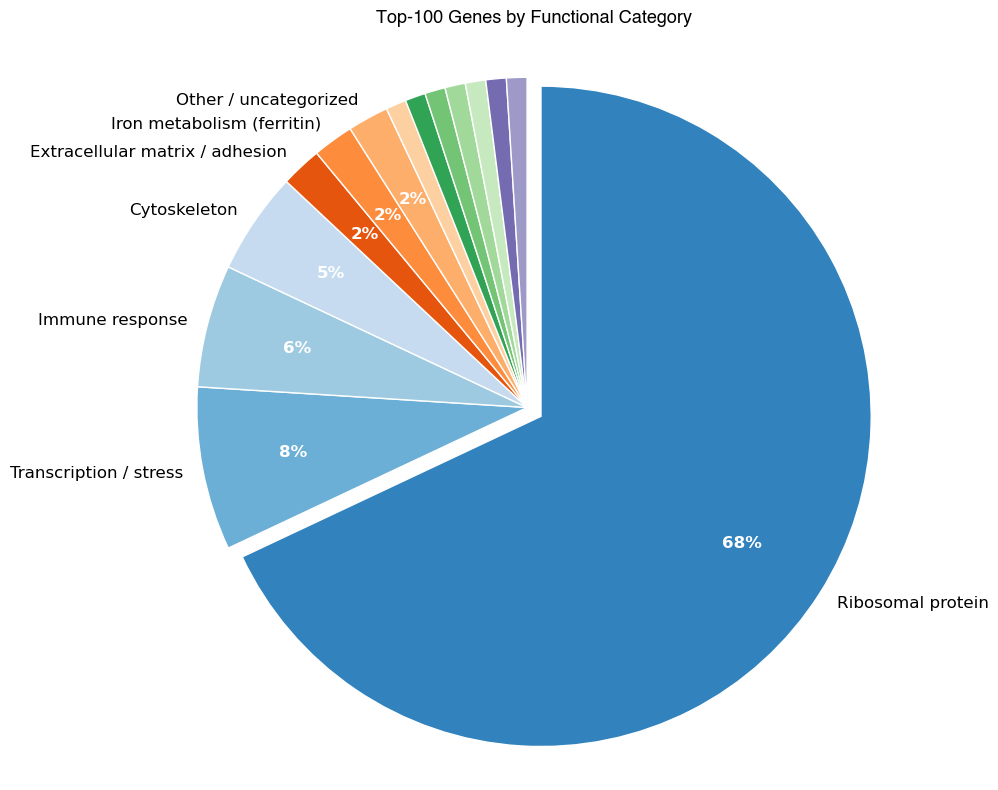

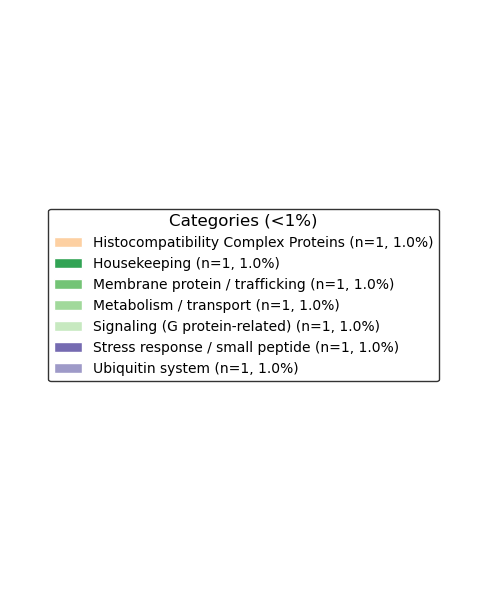

In [39]:
threshold = 1.5  # % cutoff for labeling on the pie

d = df.copy().sort_values("percent", ascending=False).reset_index(drop=True)
explode = [0.05 if i == 0 else 0 for i in range(len(d))]

colors = plt.cm.tab20c.colors[:len(d)]

# Create main pie chart figure (without legend)
fig, ax = plt.subplots(figsize=(10, 8))

def autopct_fmt(pct):
    return f"{pct:.0f}%" if pct >= threshold else ""

pie_labels = [cat if pct >= threshold else "" 
              for cat, pct in zip(d["Category"], d["percent"])]

wedges, texts, autotexts = ax.pie(
    d["percent"],
    labels=pie_labels,
    autopct=autopct_fmt,
    startangle=90,
    counterclock=False,
    explode=explode,
    colors=colors,
    wedgeprops=dict(edgecolor="white", linewidth=1),
    labeldistance=1.06,   # nudge labels a touch outward
    pctdistance=0.72      # keep % inside the wedge
)

for t in texts:
    t.set_fontsize(12)
for at in autotexts:
    at.set_fontsize(12)
    at.set_color("white")
    at.set_weight("bold")

ax.set_title("Top-100 Genes by Functional Category", fontsize=13, fontname="helvetica", pad=15)
ax.axis("equal")
plt.tight_layout()  # Changed from rect=[0, 0, 1, 0.75]
plt.savefig("Classification_pie_top100_no_legend.png", dpi=600, bbox_inches="tight")
plt.show()

# Create separate legend figure
mask_small = d["percent"] < threshold
small_idx = [i for i, m in enumerate(mask_small) if m]

if len(small_idx) > 0:  # Only create legend if there are small categories
    legend_handles = [wedges[i] for i in small_idx]
    legend_labels = [f"{d.loc[i,'Category']} (n={int(d.loc[i,'count'])}, {d.loc[i,'percent']:.1f}%)"
                    for i in small_idx]
    
    # Create figure for legend only
    fig_legend = plt.figure(figsize=(5, 6))
    ax_legend = fig_legend.add_subplot(111)
    ax_legend.axis('off')
    
    # Create the legend
    legend = ax_legend.legend(
        legend_handles, legend_labels,
        title=f"Categories (<{int(threshold)}%)",
        title_fontsize=12,
        fontsize=10,
        loc="center",
        frameon=True,
        fancybox=True,
        shadow=False
    )
    
    # Style the legend
    legend.get_frame().set_facecolor('white')
    legend.get_frame().set_edgecolor('black')
    legend.get_frame().set_linewidth(1)
    
    # Save legend figure
    plt.tight_layout()
    plt.savefig("Classification_pie_legend_only.png", dpi=600, bbox_inches="tight")
    plt.show()